In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv("data/stud.csv")

In [4]:
print(df.head())
print(df.shape)


   gender race_ethnicity parental_level_of_education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test_preparation_course  math_score  reading_score  writing_score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  
(1000, 8)


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race_ethnicity               1000 non-null   str  
 2   parental_level_of_education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test_preparation_course      1000 non-null   str  
 5   math_score                   1000 non-null   int64
 6   reading_score                1000 non-null   int64
 7   writing_score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


## Data checks to perform
#### Missing values
#### Duplicates
#### data type
#### number of unique columns
#### statistics of data set
#### Categories present in various columns

In [6]:
df.isna().sum() #no missing values in the data set

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [7]:
df.duplicated().sum()   #no duplicates in data set

np.int64(0)

In [8]:
#is duplicates was present
# df = df.drop_duplicates()  
# df.drop_duplicates(subset=["Name", "Age"])   duplicates only in name and age


In [9]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [10]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## Exploring data

In [11]:
for i in df.columns:
    print(f"Categories in {i} variable:")
    print(df[i].unique())

Categories in gender variable:
<StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in race_ethnicity variable:
<StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in parental_level_of_education variable:
<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in lunch variable:
<StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in test_preparation_course variable:
<StringArray>
['none', 'completed']
Length: 2, dtype: str
Categories in math_score variable:
[ 72  69  90  47  76  71  88  40  64  38  58  65  78  50  18  46  54  66
  44  74  73  67  70  62  63  56  97  81  75  57  55  53  59  82  77  33
  52   0  79  39  45  60  61  41  49  30  80  42  27  43  68  85  98  87
  51  99  84  91  83  89  22 100  96  94  48  35  34  86  92  37  28  24
  26  95  36  29  32  93  19  23 

In [20]:
numeric_features = [i for i in df.columns if df[i].dtype in ['int64', 'float64', 'int32', 'float32']]
categorical_features = [i for i in df.columns if df[i].dtype == 'O' or df[i].dtype.name == 'category']

print(f"We have {len(numeric_features)} numerical features: {numeric_features}")
print(f"We have {len(categorical_features)} categorical features: {categorical_features}")

We have 5 numerical features: ['math_score', 'reading_score', 'writing_score', 'Total Score', 'Average Score']
We have 0 categorical features: []


In [13]:
df['Total Score']=df['reading_score']+df['math_score']+df['writing_score']
df['Average Score']=df['Total Score']/3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total Score,Average Score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [14]:
reading_full=df[df['reading_score']==100]['Average Score'].count()
math_full=df[df['math_score']==100]['Average Score'].count()
writing_full=df[df['writing_score']==100]['Average Score'].count()

print(f"Number of students with full marks in reading : {reading_full}")
print(f"Number of students with full marks in writing : {writing_full}")
print(f"Number of students with full marks in math : {math_full}")

Number of students with full marks in reading : 17
Number of students with full marks in writing : 14
Number of students with full marks in math : 7


In [15]:
reading_20=df[df['reading_score']<20]['Average Score'].count()
math_20=df[df['math_score']<20]['Average Score'].count()
writing_20=df[df['writing_score']<20]['Average Score'].count()

print(f"Number of students with less than 20 marks in reading : {reading_20}")
print(f"Number of students with less than 20 marks in writing : {writing_20}")
print(f"Number of students with less than 20 marks in math : {math_20}")

Number of students with less than 20 marks in reading : 1
Number of students with less than 20 marks in writing : 3
Number of students with less than 20 marks in math : 4


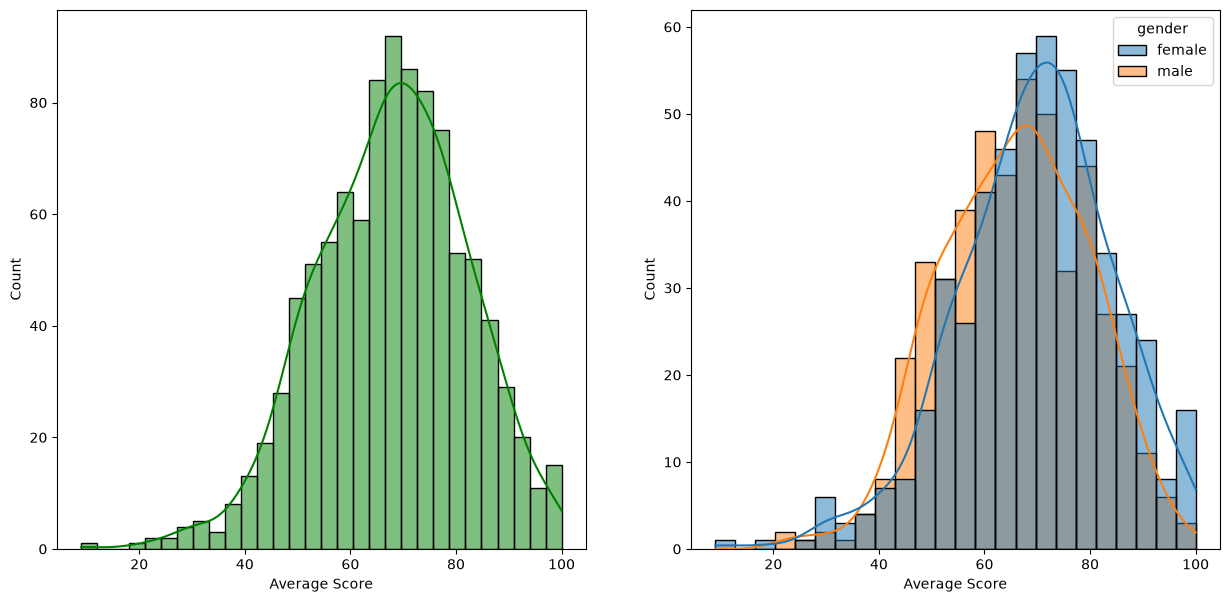

In [16]:
fig,axis=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='Average Score',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Average Score',kde=True,hue='gender')
plt.show()